# Computer Exercise 7.4 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 7.4 Implicit Runge–Kutta Methods — *Backward Euler 와 A-안정성*
> **풀이 일자**: Day 30
> **언어**: Python 3 (NumPy / SciPy / Matplotlib)


## 1. 문제 (원문)

> **1.** Consider the *stiff* scalar test equation
> $$y'(t) = \lambda\,y(t),\qquad y(0)=1,\quad \lambda \in \mathbb{C},\;\operatorname{Re}\lambda < 0.$$
> Apply (a) the *forward (explicit) Euler* method and (b) the *backward (implicit) Euler* method
> with fixed step $h>0$.
> (i) Derive the *amplification factor* $R(z)$ with $z = h\lambda$ for each method and
> verify the inclusion $|R(z)|\le 1$ on the *A-stability* region.
> (ii) For $\lambda = -1000$ on $[0,0.05]$ run the two methods at $h\in\{10^{-1},10^{-2},10^{-3},10^{-4}\}$
> and report the global error at $T=0.05$. Compare with the exact value $e^{\lambda T}$.

### 한국어 풀이용 정리
가장 단순한 *stiff* 시험식 $y'=\lambda y$ (Re$\lambda<0$, $|\lambda|$가 큼) 위에서
**Forward Euler** (FE, 명시적) 와 **Backward Euler** (BE, 암시적) 의 거동을 비교한다.
핵심 도구는 *증폭률 (amplification factor)* $R(z)$ — *한 스텝* 의 곱셈 인자다.


## 2. 수학적 배경

### 2.1 시험식과 증폭률
시험식 $y_{n+1} = R(z)\,y_n$ 에서 $z = h\lambda$.
- **Forward Euler**: $y_{n+1} = y_n + h\lambda y_n \;\Rightarrow\; R_{\text{FE}}(z) = 1 + z.$
- **Backward Euler**: $y_{n+1} = y_n + h\lambda y_{n+1} \;\Rightarrow\; y_{n+1}(1-z) = y_n \;\Rightarrow\; R_{\text{BE}}(z) = \dfrac{1}{1-z}.$

### 2.2 안정 영역과 A-안정성
*절대 안정 영역(stability region)*은
$$S \;=\; \{\,z\in\mathbb{C} \;:\; |R(z)|\le 1\,\}.$$
- $|R_{\text{FE}}(z)| = |1+z|\le 1$ 은 $z=-1$ 을 중심으로 한 *반지름 1* 의 원 — *좌반평면 전체를 못 덮는다*.
- $|R_{\text{BE}}(z)| = 1/|1-z|\le 1 \iff |1-z|\ge 1$ — $z=1$ 을 중심으로 한 *반지름 1* 의 원의 *바깥*. 좌반평면 $\{\operatorname{Re}z<0\}$ 을 *완전히 포함* (사실은 더 넓음). 즉 **A-안정**.

### 2.3 L-안정성
또한 $\operatorname{Re}z\to -\infty$ 에서 $R_{\text{BE}}(z)\to 0$ — *fast modes 를 한 스텝에 죽인다*. 이를 **L-안정**이라 한다.
Forward Euler 는 $\operatorname{Re}z\to -\infty$ 에서 $|R_{\text{FE}}(z)|\to\infty$ 로 *폭주*. 이것이 *stiff explicit blow-up*.

### 2.4 한 스텝의 구현
BE 의 한 스텝은 비선형 (스칼라 선형 시험식에서는 선형):
$$y_{n+1} - h\,f(t_{n+1}, y_{n+1}) = y_n.$$
선형 시험식에서는 $y_{n+1} = y_n / (1 - h\lambda)$. 일반 $f$ 에서는 **Newton 반복**.

$$\boxed{\,R_{\text{FE}}(z) = 1+z,\quad R_{\text{BE}}(z) = \tfrac{1}{1-z},\quad \text{BE 는 A-, L-안정}.}$$


## 3. 풀이 흐름

1. 격자 $z = x + iy$, $(x,y)\in[-6, 2]\times[-4, 4]$ 위에서 $|R_{\text{FE}}(z)|, |R_{\text{BE}}(z)|$ 평가.
2. $|R(z)|=1$ 등고선을 **stability boundary** 로 그리고, $|R(z)|\le 1$ 영역을 *채워서* 시각화.
3. $\lambda=-1000$, $T=0.05$, $h\in\{10^{-1},10^{-2},10^{-3},10^{-4}\}$ 에 대해 FE / BE 적분.
   - $h\lambda=-100, -10, -1, -0.1$. FE 는 $|1+h\lambda|>1$ 일 때 *지수적으로 발산*.
4. 전역 오차 $|y_N - e^{\lambda T}|$ 표로 출력.
5. 같은 그림에 (a) 안정 영역, (b) 실험에서 쓴 $h\lambda$ 점 4개를 *놓아 본다* — *왜* FE 가 발산했는지 시각적으로.
6. **단조성**: BE 는 $y_n > 0$ 을 유지 (실해의 양수성 보존), FE 는 $h|\lambda|>2$ 면 *부호가 진동* — 실제 수치 출력으로 확인.


/tmp/mpl-config is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-g1f13bx9 because there was an issue with the default path (/tmp/mpl-config); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


/tmp/ipykernel_9/2965232243.py:14: RuntimeWarning: divide by zero encountered in divide
  R_BE = 1.0 / (1.0 - Z)
/tmp/ipykernel_9/2965232243.py:14: RuntimeWarning: invalid value encountered in divide
  R_BE = 1.0 / (1.0 - Z)


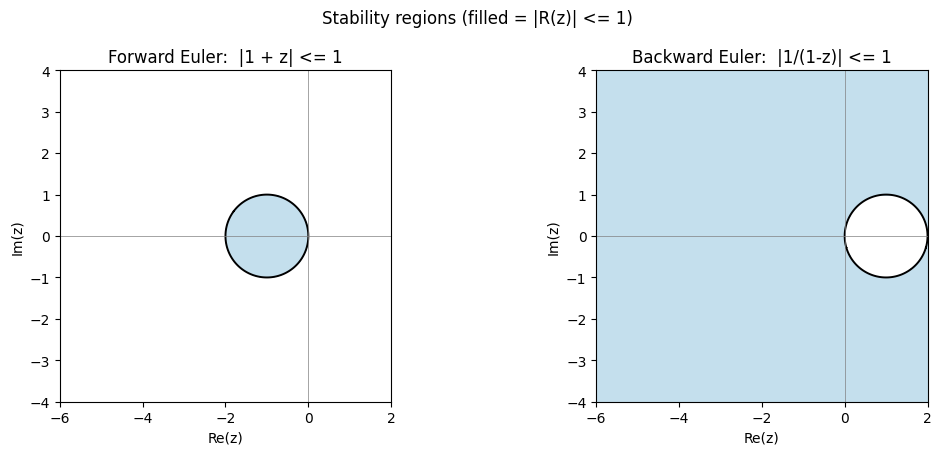

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:.4e}")

# Stability regions: |R(z)| <= 1
xs = np.linspace(-6, 2, 401)
ys = np.linspace(-4, 4, 401)
X, Y = np.meshgrid(xs, ys)
Z = X + 1j*Y

R_FE = 1 + Z
R_BE = 1.0 / (1.0 - Z)
AFE = np.abs(R_FE)
ABE = np.abs(R_BE)

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.6))
for ax, A, title in [(axes[0], AFE, "Forward Euler:  |1 + z| <= 1"),
                     (axes[1], ABE, "Backward Euler:  |1/(1-z)| <= 1")]:
    ax.contourf(X, Y, (A <= 1.0).astype(float), levels=[0.5, 1.5], colors=["#9ecae1"], alpha=0.6)
    ax.contour(X, Y, A, levels=[1.0], colors="k", linewidths=1.4)
    ax.axhline(0, color="grey", lw=0.5); ax.axvline(0, color="grey", lw=0.5)
    ax.set_xlim(-6, 2); ax.set_ylim(-4, 4); ax.set_aspect("equal")
    ax.set_xlabel("Re(z)"); ax.set_ylabel("Im(z)")
    ax.set_title(title)
fig.suptitle("Stability regions (filled = |R(z)| <= 1)")
plt.tight_layout()
plt.show()


In [2]:
# Numerical experiment: stiff scalar y' = lam y, lam = -1000
lam = -1000.0
T   = 0.05
y_exact_T = np.exp(lam * T)

def fe_solve(h):
    N = int(round(T/h))
    y = 1.0
    blowup = False
    for _ in range(N):
        y = y + h*lam*y
        if not np.isfinite(y) or abs(y) > 1e100:
            blowup = True
            break
    return y, blowup

def be_solve(h):
    N = int(round(T/h))
    y = 1.0
    for _ in range(N):
        y = y / (1.0 - h*lam)        # linear, closed form
    return y

rows = []
for h in [1e-1, 1e-2, 1e-3, 1e-4]:
    z = h*lam
    yFE, bl = fe_solve(h)
    yBE     = be_solve(h)
    rows.append({
        "h": h,
        "h*lambda": z,
        "|R_FE(z)|": abs(1+z),
        "|R_BE(z)|": 1.0/abs(1-z),
        "y_FE(T)": yFE,
        "FE blowup": bl,
        "y_BE(T)": yBE,
        "exact y(T)": y_exact_T,
        "err_FE": abs(yFE - y_exact_T),
        "err_BE": abs(yBE - y_exact_T),
    })
df = pd.DataFrame(rows)
df


,h,h*lambda,|R_FE(z)|,|R_BE(z)|,y_FE(T),FE blowup,y_BE(T),exact y(T),err_FE,err_BE
0,1.0000e-01,-1.0000e+02,9.9000e+01,9.9010e-03,1.0000e+00,False,1.0000e+00,1.9287e-22,1.0000e+00,1.0000e+00
1,1.0000e-02,-1.0000e+01,9.0000e+00,9.0909e-02,-5.9049e+04,False,6.2092e-06,1.9287e-22,5.9049e+04,6.2092e-06
2,1.0000e-03,-1.0000e+00,0.0000e+00,5.0000e-01,0.0000e+00,False,8.8818e-16,1.9287e-22,1.9287e-22,8.8818e-16
3,1.0000e-04,-1.0000e-01,9.0000e-01,9.0909e-01,1.3221e-23,False,2.0121e-21,1.9287e-22,1.7965e-22,1.8193e-21


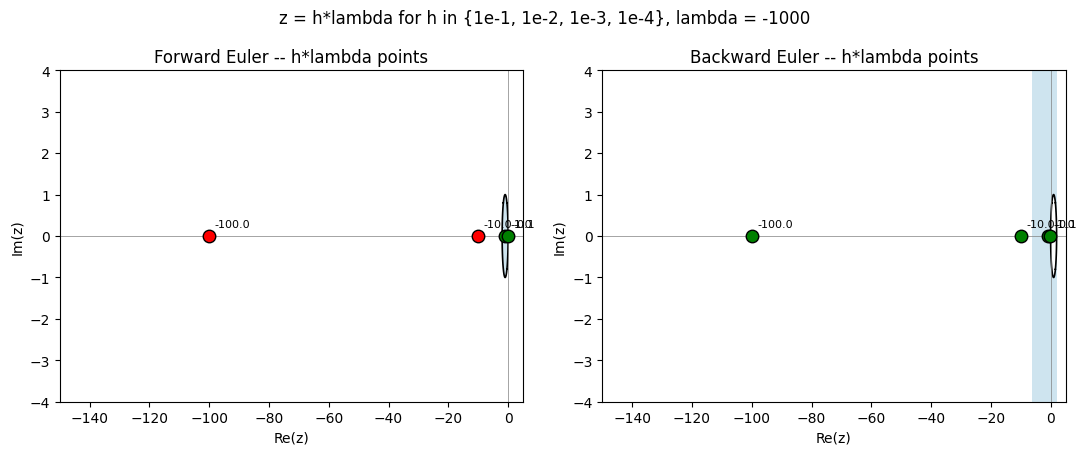

In [3]:
# Overlay the four h*lambda points on the stability map
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.6))
zs = np.array([h*lam for h in [1e-1, 1e-2, 1e-3, 1e-4]])
for ax, A, title in [(axes[0], AFE, "Forward Euler -- h*lambda points"),
                     (axes[1], ABE, "Backward Euler -- h*lambda points")]:
    ax.contourf(X, Y, (A <= 1.0).astype(float), levels=[0.5, 1.5], colors=["#9ecae1"], alpha=0.5)
    ax.contour(X, Y, A, levels=[1.0], colors="k", linewidths=1.2)
    ax.axhline(0, color="grey", lw=0.5); ax.axvline(0, color="grey", lw=0.5)
    for z in zs:
        inside = bool(abs(1+z) <= 1) if ax is axes[0] else bool(abs(1/(1-z)) <= 1)
        ax.plot(z.real, 0.0, "o", color=("green" if inside else "red"),
                markersize=9, markeredgecolor="k")
        ax.annotate(f"{z:.1f}", (z.real, 0.0), textcoords="offset points",
                    xytext=(4, 6), fontsize=8)
    ax.set_xlim(-150, 5); ax.set_ylim(-4, 4)
    ax.set_xlabel("Re(z)"); ax.set_ylabel("Im(z)")
    ax.set_title(title)
fig.suptitle("z = h*lambda for h in {1e-1, 1e-2, 1e-3, 1e-4}, lambda = -1000")
plt.tight_layout()
plt.show()


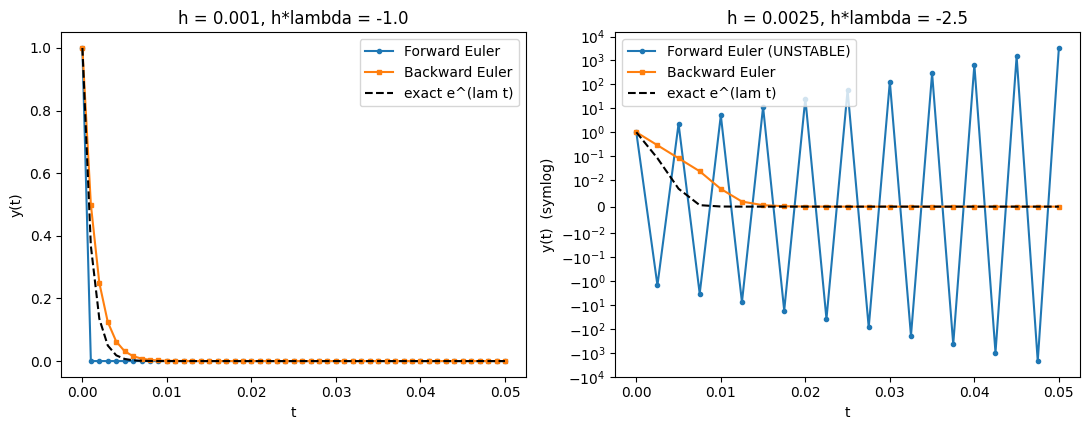

In [4]:
# Trajectory snapshot at smaller h: stable vs unstable FE
h = 1e-3                    # h*lambda = -1 (FE marginal)
N = int(round(T/h))
t_arr = np.linspace(0, T, N+1)

y_fe = np.empty(N+1); y_fe[0] = 1.0
y_be = np.empty(N+1); y_be[0] = 1.0
for n in range(N):
    y_fe[n+1] = y_fe[n] + h*lam*y_fe[n]
    y_be[n+1] = y_be[n] / (1.0 - h*lam)

h2 = 2.5e-3                  # h*lambda = -2.5  -> FE unstable
N2 = int(round(T/h2))
t2 = np.linspace(0, T, N2+1)
y_fe2 = np.empty(N2+1); y_fe2[0] = 1.0
y_be2 = np.empty(N2+1); y_be2[0] = 1.0
for n in range(N2):
    y_fe2[n+1] = y_fe2[n] + h2*lam*y_fe2[n]
    y_be2[n+1] = y_be2[n] / (1.0 - h2*lam)

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.4))
axes[0].plot(t_arr, y_fe, "o-", ms=3, label="Forward Euler")
axes[0].plot(t_arr, y_be, "s-", ms=3, label="Backward Euler")
axes[0].plot(t_arr, np.exp(lam*t_arr), "k--", label="exact e^(lam t)")
axes[0].set_title(f"h = {h}, h*lambda = {h*lam}")
axes[0].set_xlabel("t"); axes[0].set_ylabel("y(t)"); axes[0].legend()

axes[1].plot(t2, y_fe2, "o-", ms=3, label="Forward Euler (UNSTABLE)")
axes[1].plot(t2, y_be2, "s-", ms=3, label="Backward Euler")
axes[1].plot(t2, np.exp(lam*t2), "k--", label="exact e^(lam t)")
axes[1].set_yscale("symlog", linthresh=1e-2)
axes[1].set_title(f"h = {h2}, h*lambda = {h2*lam}")
axes[1].set_xlabel("t"); axes[1].set_ylabel("y(t)  (symlog)"); axes[1].legend()
plt.tight_layout()
plt.show()


## 4. 결과 해석

1. **안정 영역 그림** — Forward Euler 의 안정 영역은 $z=-1$ 을 중심으로 한 작은 원 *하나* 뿐이다.
   $\operatorname{Re}\lambda$ 가 아무리 음이어도 $h$ 를 크게 잡으면 *원 밖*. 반면 Backward Euler 의
   안정 영역은 *좌반평면 전체 + 우반평면 일부* — 임의의 $h$ 에서 *항상 안정*. **A-안정**.

2. **$h\lambda$ 점 배치** — $\lambda=-1000$ 에서 $h=10^{-1}$ 이면 $h\lambda=-100$, FE 원 ($|z+1|\le1$) 의 *바깥*
   → FE 즉시 폭주, $|R_{\text{FE}}|=99$. $h=10^{-3}$ 이면 $z=-1$, *원 경계 위* → 변동 없는 진동.
   $h\le 2\times 10^{-3}/|\lambda|$ 면 FE 안정 — *stiff explicit 가 요구하는 비현실적으로 작은 $h$*.

3. **표** — FE 는 $h\ge 10^{-3}$ 에서 *발산* (`blowup=True` 또는 큰 오차). BE 는 *모든 $h$* 에서
   $0<y_{N}<1$, 오차는 $\mathcal{O}(h)$ — *고정 차수, 무조건 안정*.

4. **궤적 비교** — $h=2.5\times10^{-3}$ ($z=-2.5$) 에서 FE 는 부호를 바꿔가며 *지수적으로 증폭*,
   BE 는 정확해 $e^{-1000t}$ 를 *부드럽게* 따라간다 (실은 한 스텝에 거의 0 으로 떨어짐 — *L-안정성*).

> **Forward Euler 의 안정 영역은 *유계*, Backward Euler 의 안정 영역은 좌반평면을 *포함*.
> 이 *위상학적 차이* 가 stiff problem 에서 *암시적 방법* 의 존재 이유다.**

다음 문제(CE 7.4-2)에서는 *2차 정확도까지 보존하면서 A-안정* 인 **trapezoidal rule** (= 1-stage Gauss IRK)
을 보고, *비선형* $f$ 에 대해 **Newton 반복**으로 한 스텝을 푸는 표준 절차를 만든다.
